In [19]:
import ast
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
embeddings_path = "../data/swissprot_embeddings.npy"
ids_path = "../data/swissprot_ids.txt"


embeddings = np.load(embeddings_path, mmap_mode="r")

with open(ids_path, "r") as f:
    all_ids = [line.strip() for line in f if line.strip()]

print(f"Embeddings file shape: {embeddings.shape}")
print(f"{len(embeddings)}")
print(f"{len(all_ids)}")
assert len(embeddings) == len(all_ids), f"Mismatch: {len(embeddings)} vs {len(all_ids)}"

Embeddings file shape: (547205, 1280)
547205
547205


In [8]:
csv_path = '../data/swissprot_clean.csv'

df = pd.read_csv(csv_path)
df["keywords"] = df["keywords"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["keyword_label"] = df["keywords"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)
# First keyword used for coloring — simplification, order is not ranked by importance

In [14]:
top_10_labels = df["keyword_label"].value_counts().head(10).index
df_top10 = df[df["keyword_label"].isin(top_10_labels)]

top_10 = df["keyword_label"].value_counts().head(10)

for label, count in top_10.items():
    print(f"{label}: {count}")

Cytoplasm: 65028
ATP-binding: 51259
Reference proteome: 39545
3D-structure: 35081
Amino-acid biosynthesis: 22420
Cell membrane: 18705
Ribonucleoprotein: 17587
Cell inner membrane: 14724
Acetylation: 12774
Aminoacyl-tRNA synthetase: 12141


In [17]:
id_to_idx = {uid: i for i, uid in enumerate(all_ids)}
samples = []

for cat in df_top10["keyword_label"].unique():
    df_cat = df_top10[df_top10["keyword_label"] == cat]
    
    sampled = df_cat.sample(
        n=min(500, len(df_cat)),
        random_state=42
    )
    
    samples.append(sampled)

df_sampled = pd.concat(samples).reset_index(drop=True)
sampled_indices = df_sampled["id"].map(id_to_idx).dropna().astype(int).values
subsampled_embeddings = embeddings[sampled_indices]
assert len(sampled_indices) == len(df_sampled), "Some IDs not found in ids file"

In [18]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(subsampled_embeddings)
print(f"UMAP output shape: {embedding_2d.shape}")

/home/godfather/Personal_Projects/AI-Bioinformatics-Projects/Protein_Sequence_Similarity_Search_Microservice/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (5000, 2)


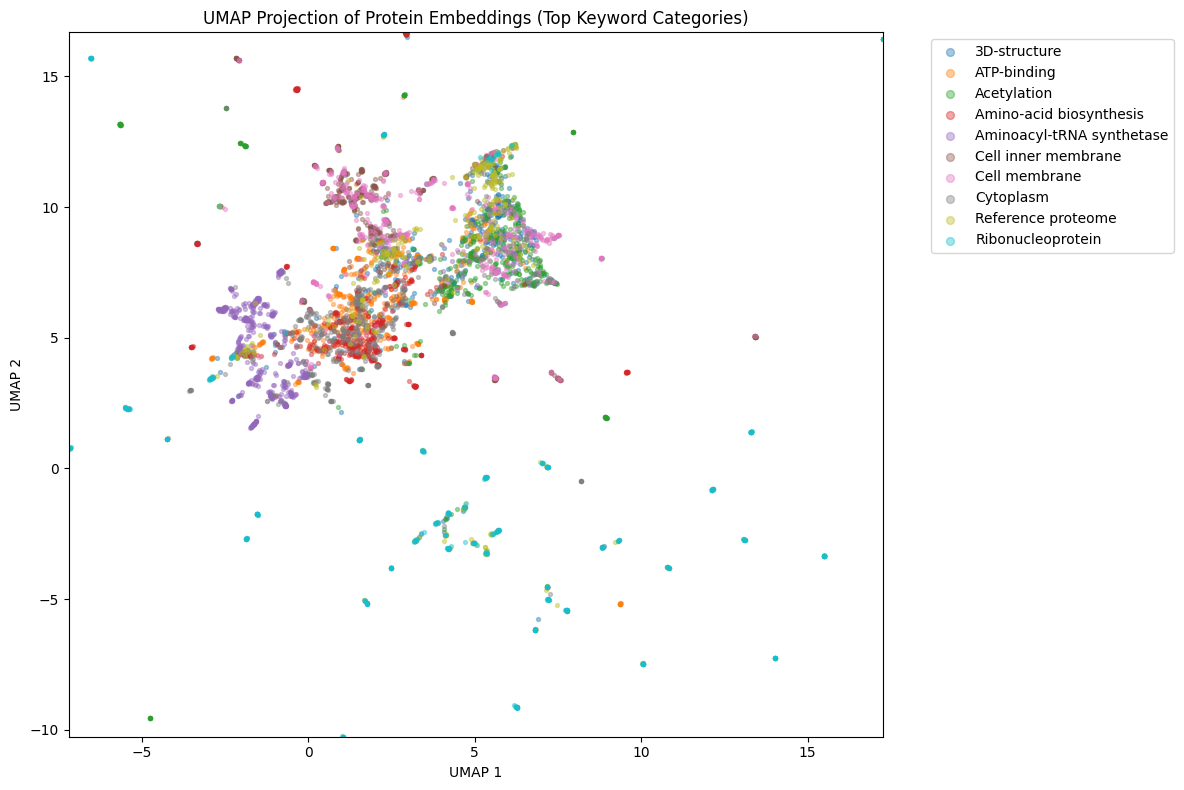

: 

In [ ]:
labels = df_sampled["keyword_label"].values

plt.figure(figsize=(12, 8))
categories = np.unique(labels)
colors = dict(zip(categories, plt.cm.tab10.colors))
for cat in categories:
    mask = labels == cat
    plt.scatter(
        embedding_2d[mask, 0],
        embedding_2d[mask, 1],
        label=cat,
        s=8,
        alpha=0.4,
        color=colors[cat]
    )

plt.title("UMAP Projection of Protein Embeddings (Top Keyword Categories)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.xlim(np.percentile(embedding_2d[:, 0], [1, 99]))
plt.ylim(np.percentile(embedding_2d[:, 1], [1, 99]))
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The UMAP projection of 5,000 subsampled ESM-2 embeddings reveals a dense central region where most keyword categories overlap, with partial separation visible for functionally specific categories such as Aminoacyl-tRNA synthetase and Ribonucleoprotein. The heavy mixing in the core is expected — keywords such as "Reference proteome" and "Acetylation" are metadata annotations that co-occur across functionally diverse proteins, making clean separation unlikely under first-keyword coloring. This plot is a visualization aid; geometric proximity in UMAP space reflects local neighborhood structure preserved from the high-dimensional embedding and should not be interpreted as evidence of categorical separability.